# Reproducing Zhu & Rivera (2002), Figure 1

Zhu & Rivera (GJI 148, 2002) introduce the unified dynamic / static
F-K formulation that underlies Lupei Zhu's `fk` Fortran code.  Their
Figure 1 compares synthetic vertical and radial seismograms for a
double-couple in a layered halfspace at several distances.

Here we reproduce that style of figure with `fkpy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fkpy import LayeredModel, compute_greens, ZhuBasis

## Model: Hadley-Kanamori-style 3-layer crust

Same parameters as `tests/data/canonical_zhu5.model`.

In [2]:
model_array = np.array([
    [10.0, 6.3, 3.5, 2.786, 1000.0, 500.0],
    [25.0, 6.3, 3.5, 2.786, 1000.0, 500.0],
    [0.0,  8.1, 4.7, 3.362, 1600.0, 800.0],   # half-space
])
model = LayeredModel.from_array(model_array)
print(model)

LayeredModel(n_layers=3)


In [3]:
distances = np.array([100.0, 150.0, 200.0])
result = compute_greens(
    model=model,
    src_depth_km=10.0,
    distances_km=distances,
    npts=512,
    dt=0.2,
    sigma=2.0,
    taper=0.5,
    samples_before_p=25,
    n_workers=1,
    hipass=(1, 1),
)
print('GF shape:', result.gf.shape)

GF shape: (3, 10, 512)


## Plot the 9 double-couple components

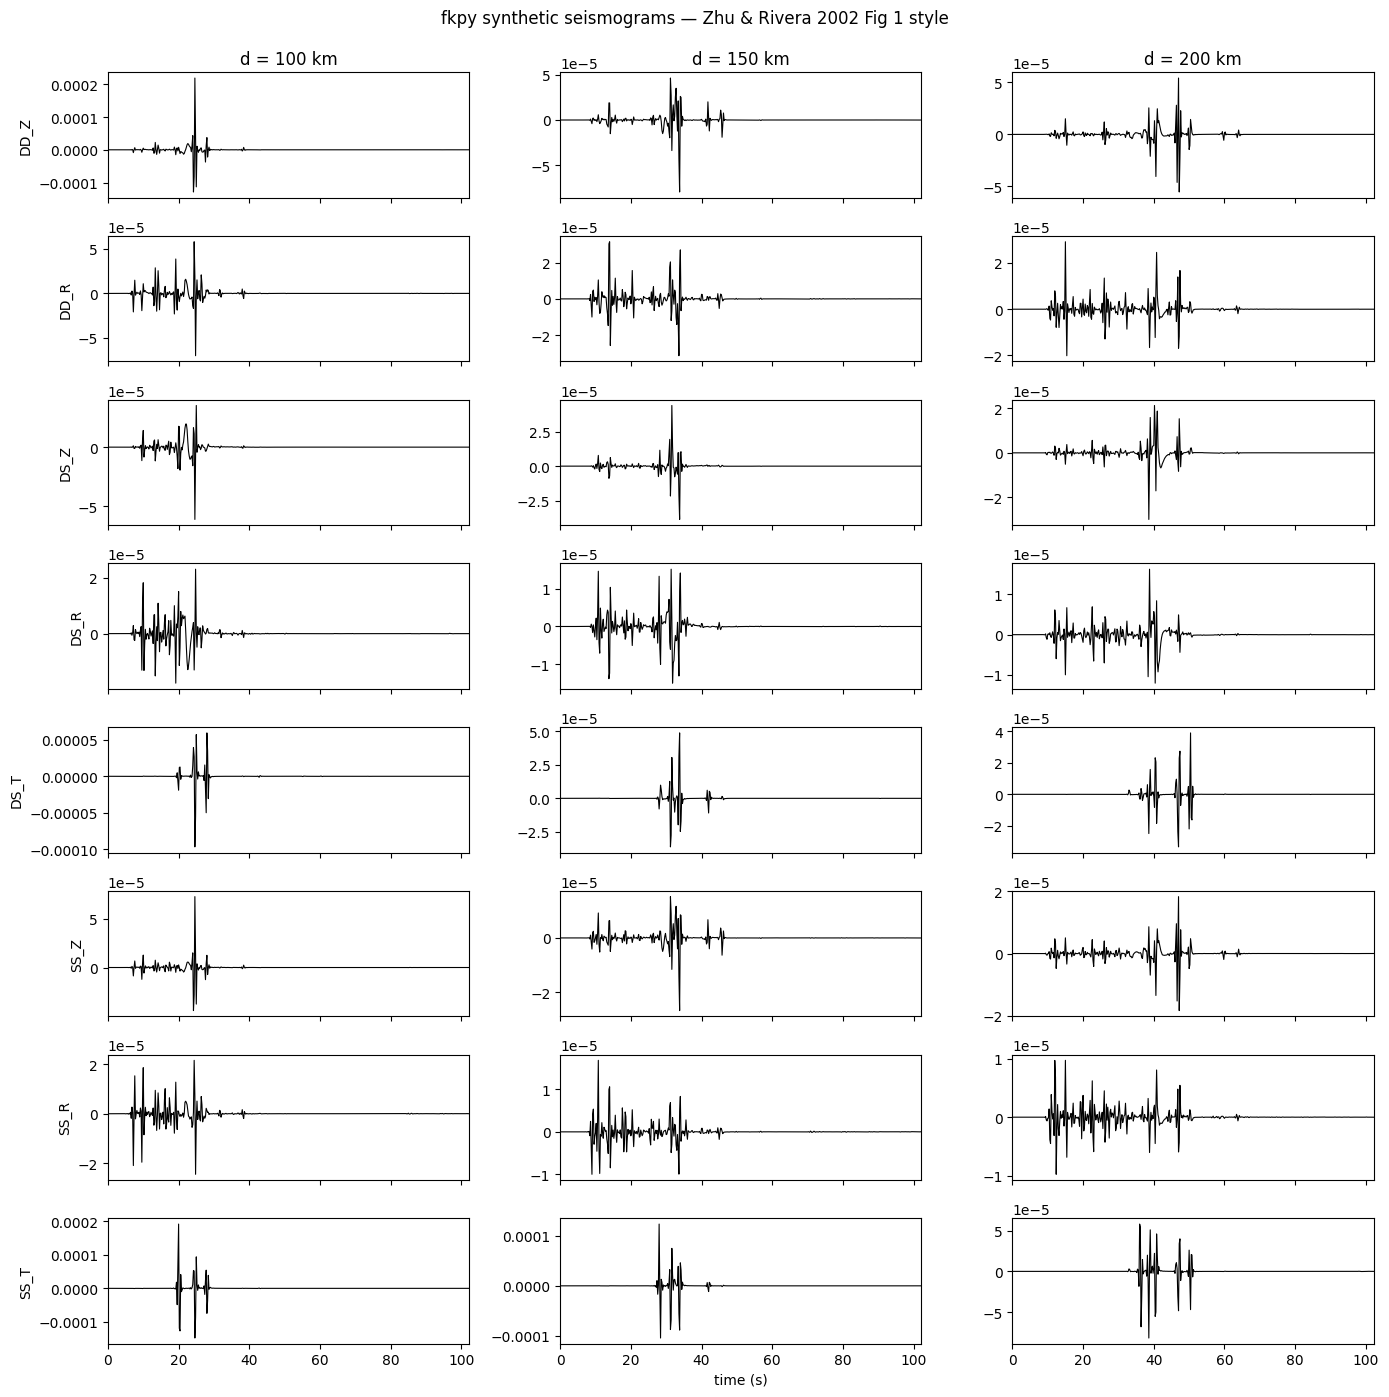

In [4]:
components = [ZhuBasis.DD_Z, ZhuBasis.DD_R, ZhuBasis.DS_Z, ZhuBasis.DS_R, ZhuBasis.DS_T,
              ZhuBasis.SS_Z, ZhuBasis.SS_R, ZhuBasis.SS_T]
names = ['DD_Z', 'DD_R', 'DS_Z', 'DS_R', 'DS_T', 'SS_Z', 'SS_R', 'SS_T']
fig, axes = plt.subplots(len(components), len(distances), figsize=(14, 14), sharex=True)
for ic, (comp, name) in enumerate(zip(components, names)):
    for id_, dist in enumerate(distances):
        ax = axes[ic, id_]
        t = np.arange(result.npts) * result.dt
        ax.plot(t, result.gf[id_, int(comp)], 'k', lw=0.8)
        if ic == 0:
            ax.set_title(f'd = {dist:g} km')
        if id_ == 0:
            ax.set_ylabel(name)
        ax.set_xlim(0, t[-1])
axes[-1, 1].set_xlabel('time (s)')
fig.suptitle("fkpy synthetic seismograms — Zhu & Rivera 2002 Fig 1 style", y=0.995)
fig.tight_layout()
plt.show()